# Buisness Problem

## A Retail store is required to analyze the day-to-day transactions and keep a track of its customers spread across various locations along with their purchases/returns across various categories.
## Create a report and display the below calculated metrics, reports and inferences.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime
import seaborn as sns

In [2]:
cust = pd.read_csv('./Case Study 1 - Retail Case Study/Customer.csv')
products = pd.read_csv('./Case Study 1 - Retail Case Study/prod_cat_info.csv')
tran = pd.read_csv('./Case Study 1 - Retail Case Study/Transactions.csv')

In [3]:
cust

,customer_Id,DOB,Gender,city_code
0,268408,02-01-1970,M,4.0
1,269696,07-01-1970,F,8.0
2,268159,08-01-1970,F,8.0
3,270181,10-01-1970,F,2.0
4,268073,11-01-1970,M,1.0
...,...,...,...,...
5642,274474,19-12-1992,M,2.0
5643,267666,24-12-1992,M,6.0
5644,270476,25-12-1992,F,3.0
5645,269626,27-12-1992,F,5.0


In [7]:
products

,prod_cat_code,prod_cat,prod_sub_cat_code,prod_subcat
0,1,Clothing,4,Mens
1,1,Clothing,1,Women
2,1,Clothing,3,Kids
3,2,Footwear,1,Mens
4,2,Footwear,3,Women
5,2,Footwear,4,Kids
6,3,Electronics,4,Mobiles
7,3,Electronics,5,Computers
8,3,Electronics,8,Personal Appliances
9,3,Electronics,9,Cameras


In [9]:
tran

,transaction_id,cust_id,tran_date,prod_subcat_code,prod_cat_code,Qty,Rate,Tax,total_amt,Store_type
0,80712190438,270351,28-02-2014,1,1,-5,-772,405.300,-4265.300,e-Shop
1,29258453508,270384,27-02-2014,5,3,-5,-1497,785.925,-8270.925,e-Shop
2,51750724947,273420,24-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop
3,93274880719,271509,24-02-2014,11,6,-3,-1363,429.345,-4518.345,e-Shop
4,51750724947,273420,23-02-2014,6,5,-2,-791,166.110,-1748.110,TeleShop
...,...,...,...,...,...,...,...,...,...,...
23048,94340757522,274550,25-01-2011,12,5,1,1264,132.720,1396.720,e-Shop
23049,89780862956,270022,25-01-2011,4,1,1,677,71.085,748.085,e-Shop
23050,85115299378,271020,25-01-2011,2,6,4,1052,441.840,4649.840,MBR
23051,72870271171,270911,25-01-2011,11,5,3,1142,359.730,3785.730,TeleShop


## Joining Dataset

In [18]:
cust_tran = pd.merge(cust,tran, left_on = cust.customer_Id , right_on = tran.cust_id)

In [20]:
cust_tran.drop(columns='key_0',inplace=True)

In [22]:
Customer_Final = pd.merge(cust_tran , products , left_on = [cust_tran.prod_subcat_code , cust_tran.prod_cat_code] , right_on = [products.prod_sub_cat_code , products.prod_cat_code])	

In [24]:
Customer_Final.drop(columns='cust_id',inplace=True)

## EDA & Cleaning

In [21]:
Customer_Final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23053 entries, 0 to 23052
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   key_0              23053 non-null  int64  
 1   key_1              23053 non-null  int64  
 2   customer_Id        23053 non-null  int64  
 3   DOB                23053 non-null  object 
 4   Gender             23044 non-null  object 
 5   city_code          23045 non-null  float64
 6   transaction_id     23053 non-null  int64  
 7   tran_date          23053 non-null  object 
 8   prod_subcat_code   23053 non-null  int64  
 9   prod_cat_code_x    23053 non-null  int64  
 10  Qty                23053 non-null  int64  
 11  Rate               23053 non-null  int64  
 12  Tax                23053 non-null  float64
 13  total_amt          23053 non-null  float64
 14  Store_type         23053 non-null  object 
 15  prod_cat_code_y    23053 non-null  int64  
 16  prod_cat           230

In [35]:
Customer_Final.head(10)

,key_0,key_1,customer_Id,DOB,Gender,city_code,transaction_id,tran_date,prod_subcat_code,prod_cat_code_x,Qty,Rate,Tax,total_amt,Store_type,prod_cat_code_y,prod_cat,prod_sub_cat_code,prod_subcat
0,7,5,268408,02-01-1970,M,4.0,87243835584,13-01-2014,7,5,5,187,98.175,1033.175,TeleShop,5,Books,7,Fiction
1,1,4,268408,02-01-1970,M,4.0,16197868036,16-12-2013,1,4,-5,-210,110.250,-1160.250,Flagship store,4,Bags,1,Mens
2,1,4,268408,02-01-1970,M,4.0,16197868036,12/12/2013,1,4,5,210,110.250,1160.250,Flagship store,4,Bags,1,Mens
3,10,6,268408,02-01-1970,M,4.0,28810141075,2/9/2013,10,6,2,813,170.730,1796.730,TeleShop,6,Home and kitchen,10,Kitchen
4,4,2,268408,02-01-1970,M,4.0,64633435931,6/5/2013,4,2,3,312,98.280,1034.280,Flagship store,2,Footwear,4,Kids
5,9,3,268408,02-01-1970,M,4.0,56902862040,30-01-2013,9,3,5,868,455.700,4795.700,e-Shop,3,Electronics,9,Cameras
6,1,2,268408,02-01-1970,M,4.0,56844530655,14-10-2012,1,2,5,1175,616.875,6491.875,MBR,2,Footwear,1,Mens
7,10,3,268408,02-01-1970,M,4.0,19516063887,7/9/2012,10,3,4,650,273.000,2873.000,e-Shop,3,Electronics,10,Audio and video
8,4,4,268408,02-01-1970,M,4.0,12644501524,14-08-2012,4,4,3,321,101.115,1064.115,TeleShop,4,Bags,4,Women
9,1,1,268408,02-01-1970,M,4.0,63314547725,26-04-2012,1,1,1,806,84.630,890.630,Flagship store,1,Clothing,1,Women


In [37]:
Customer_Final.tail(10)

,key_0,key_1,customer_Id,DOB,Gender,city_code,transaction_id,tran_date,prod_subcat_code,prod_cat_code_x,Qty,Rate,Tax,total_amt,Store_type,prod_cat_code_y,prod_cat,prod_sub_cat_code,prod_subcat
23043,11,6,270476,25-12-1992,F,3.0,78034405353,13-08-2013,11,6,1,971,101.955,1072.955,TeleShop,6,Home and kitchen,11,Bath
23044,10,3,270476,25-12-1992,F,3.0,3359888057,16-03-2013,10,3,4,361,151.620,1595.620,MBR,3,Electronics,10,Audio and video
23045,4,2,270476,25-12-1992,F,3.0,22883386455,22-05-2012,4,2,4,898,377.160,3969.160,Flagship store,2,Footwear,4,Kids
23046,4,4,270476,25-12-1992,F,3.0,19725194268,21-02-2012,4,4,4,618,259.560,2731.560,e-Shop,4,Bags,4,Women
23047,5,3,270476,25-12-1992,F,3.0,85475160771,9/8/2011,5,3,5,1354,710.850,7480.850,Flagship store,3,Electronics,5,Computers
23048,12,6,269626,27-12-1992,F,5.0,71369029396,18-10-2011,12,6,1,638,66.990,704.990,e-Shop,6,Home and kitchen,12,Tools
23049,3,1,269626,27-12-1992,F,5.0,94134051896,7/7/2011,3,1,3,1078,339.570,3573.570,MBR,1,Clothing,3,Kids
23050,1,2,274308,29-12-1992,F,5.0,26208690928,22-10-2012,1,2,2,898,188.580,1984.580,MBR,2,Footwear,1,Mens
23051,1,2,274308,29-12-1992,F,5.0,57358822237,5/9/2012,1,2,4,876,367.920,3871.920,e-Shop,2,Footwear,1,Mens
23052,12,5,274308,29-12-1992,F,5.0,58160544337,4/7/2012,12,5,5,588,308.700,3248.700,e-Shop,5,Books,12,Academic


In [39]:
c = ['min', 'Q1', 'median', 'Q3' , 'max']
five_number_summary = Customer_Final.describe().astype(int).iloc[3:,3:7].T
five_number_summary.columns = c
five_number_summary

,min,Q1,median,Q3,max
city_code,1,3,5,8,10
transaction_id,3268991,-2147483648,-2147483648,-2147483648,-2147483648
prod_subcat_code,1,3,5,10,12
prod_cat_code_x,1,2,4,5,6


In [41]:
Customer_Final.drop(columns = ['key_0',	'key_1'],inplace = True)

In [43]:
Customer_Final.rename({'prod_cat_code_y':'prod_cat_code'},inplace=True)

In [45]:
col = Customer_Final.select_dtypes('O').drop(columns=['DOB','tran_date']).columns

In [47]:
for i in col:
    print(Customer_Final[i].value_counts())
    print('\n')

Gender
M    11811
F    11233
Name: count, dtype: int64


Store_type
e-Shop            9311
MBR               4661
Flagship store    4577
TeleShop          4504
Name: count, dtype: int64


prod_cat
Books               6069
Electronics         4898
Home and kitchen    4129
Footwear            2999
Clothing            2960
Bags                1998
Name: count, dtype: int64


prod_subcat
Women                  3048
Mens                   2912
Kids                   1997
Tools                  1062
Fiction                1043
Kitchen                1037
Children               1035
Comics                 1031
Mobiles                1031
Bath                   1023
Furnishing             1007
Non-Fiction            1004
DIY                     989
Cameras                 985
Personal Appliances     972
Academic                967
Computers               958
Audio and video         952
Name: count, dtype: int64




In [49]:
Customer_Final.drop(columns=['prod_subcat_code' , 'prod_cat_code_x'],inplace = True)

In [51]:
Customer_Final[['customer_Id','city_code','transaction_id','prod_cat_code_y','prod_sub_cat_code']]=Customer_Final[['customer_Id','city_code','transaction_id','prod_cat_code_y','prod_sub_cat_code']].astype('object')

In [53]:
Customer_Final.DOB = pd.to_datetime(Customer_Final.DOB,format = '%d-%m-%Y')

In [55]:
Customer_Final.tran_date = pd.to_datetime(Customer_Final.tran_date,format = 'mixed')

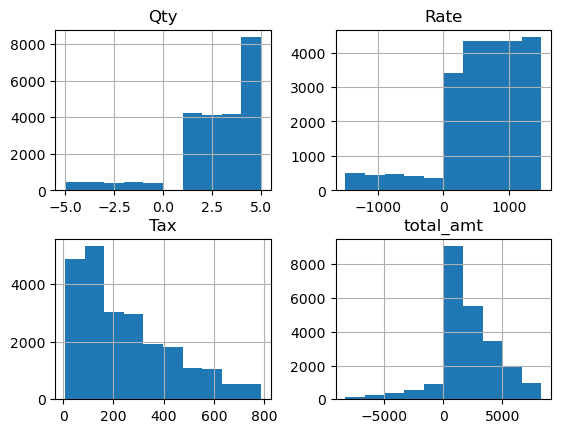

In [57]:
Customer_Final.select_dtypes(include='number').hist()
plt.show()

In [ ]:
fig , axs = plt.subplots(2,2)
Customer_Final.Gender.value_counts().plot(kind = 'bar',ax=axs[0,0])
Customer_Final.Store_type.value_counts().plot(kind = 'bar',ax=axs[0,1])
Customer_Final.prod_cat.value_counts().plot(kind = 'bar',ax=axs[1,0])
Customer_Final.prod_subcat.value_counts().plot(kind = 'bar',ax=axs[1,1])
plt.show()

In [48]:
Customer_Final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 23053 entries, 0 to 23052
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   customer_Id        23053 non-null  object        
 1   DOB                23053 non-null  datetime64[ns]
 2   Gender             23044 non-null  object        
 3   city_code          23045 non-null  object        
 4   transaction_id     23053 non-null  object        
 5   tran_date          23053 non-null  datetime64[ns]
 6   Qty                23053 non-null  int64         
 7   Rate               23053 non-null  int64         
 8   Tax                23053 non-null  float64       
 9   total_amt          23053 non-null  float64       
 10  Store_type         23053 non-null  object        
 11  prod_cat_code_y    23053 non-null  object        
 12  prod_cat           23053 non-null  object        
 13  prod_sub_cat_code  23053 non-null  object        
 14  prod_subcat

In [33]:
Customer_Final.describe().T

,count,mean,std,min,25%,50%,75%,max
key_0,23053.0,6.149091e+00,3.726372e+00,1.000,3.000000e+00,5.000000e+00,1.000000e+01,1.200000e+01
key_1,23053.0,3.763632e+00,1.677016e+00,1.000,2.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
customer_Id,23053.0,2.710217e+05,2.431692e+03,266783.000,2.689350e+05,2.709800e+05,2.731140e+05,2.752650e+05
city_code,23045.0,5.482534e+00,2.863499e+00,1.000,3.000000e+00,5.000000e+00,8.000000e+00,1.000000e+01
transaction_id,23053.0,5.007348e+10,2.898194e+10,3268991.000,2.493864e+10,5.009313e+10,7.533000e+10,9.998755e+10
prod_subcat_code,23053.0,6.149091e+00,3.726372e+00,1.000,3.000000e+00,5.000000e+00,1.000000e+01,1.200000e+01
prod_cat_code_x,23053.0,3.763632e+00,1.677016e+00,1.000,2.000000e+00,4.000000e+00,5.000000e+00,6.000000e+00
Qty,23053.0,2.432395e+00,2.268406e+00,-5.000,1.000000e+00,3.000000e+00,4.000000e+00,5.000000e+00
Rate,23053.0,6.363697e+02,6.223635e+02,-1499.000,3.120000e+02,7.100000e+02,1.109000e+03,1.500000e+03
Tax,23053.0,2.486672e+02,1.871778e+02,7.350,9.828000e+01,1.990800e+02,3.657150e+02,7.875000e+02


In [53]:
time_period = Customer_Final.tran_date.max() - Customer_Final.tran_date.min()

### Total Time Period

In [56]:
time_period

Timedelta('1430 days 00:00:00')

### No. Of Returns

In [59]:
Customer_Final.loc[Customer_Final['total_amt']  < 0 ,'total_amt'].count()

2177

### Popular Product Categories in Male and Female

In [62]:
pd.DataFrame(Customer_Final.groupby(['prod_cat','Gender']).agg({'total_amt':'sum','Qty':'sum'}).sort_values(by=['total_amt','Qty'],ascending=False)).iloc[0:2,:]

total_amt   Qty
prod_cat Gender                   
Books    M       6645972.775  7587
         F       6164692.235  7070

### City Code With Highest Customers

In [65]:
pd.DataFrame(Customer_Final.groupby('city_code').customer_Id.count()/Customer_Final.shape[0]).sort_values(by='customer_Id',ascending=False).iloc[0:1,:]

,customer_Id
city_code,
4.0,0.105062


### Most Selling Store Type

In [68]:
Customer_Final.groupby('Store_type').agg({'total_amt':'sum','customer_Id':'count'}).astype('int').sort_values(by=['total_amt','customer_Id'],ascending=False).iloc[0:1,:]

,total_amt,customer_Id
Store_type,,
e-Shop,19824816,9311


### Total amount earned from the "Electronics" and "Clothing" categories from Flagship Stores?

In [71]:
Customer_Final.loc[(Customer_Final['Store_type'] == 'Flagship store')&(Customer_Final['prod_cat'].isin(['Electronics','Clothing']))].agg({'total_amt':'sum'})

total_amt    3409559.27
dtype: float64

### Total amount earned from "Male" customers under the "Electronics" category?

In [74]:
Customer_Final.loc[(Customer_Final.Gender == 'M') & (Customer_Final.prod_cat == 'Electronics')].agg({'total_amt' : 'sum'})

total_amt    5703109.425
dtype: float64

### How many customers have more than 10 unique transactions, after removing all transactions which have any negative amounts?

In [77]:
## customers have more than 10 unique transactions
cust = pd.DataFrame(Customer_Final.customer_Id.value_counts() > 10) 

In [79]:
## Customers with positive Transactions
p_cust = Customer_Final.loc[Customer_Final['total_amt'] > 0]

In [81]:
## Filtering the CustomerID
customers_with_10_plus = cust.loc[cust['count'] == 1]

In [83]:
## Total Amount Of the customers which have positive Transactions and made more than 10 Transactions
p_cust[p_cust['customer_Id'].isin(customers_with_10_plus.index)].total_amt.sum()

920785.4500000001

## For all customers aged between 25 - 35, find out:

### a. What was the total amount spent for “Electronics” and “Books” product categories?
### b. What was the total amount spent by these customers between 1st Jan, 2014 to 1st Mar, 2014?


In [87]:
## Getting the Age From DOB Column
Customer_Final['Age'] = Customer_Final.tran_date.max() - Customer_Final['DOB']

In [89]:
Customer_Final['Age'] = Customer_Final.Age.dt.days

In [91]:
Customer_Final.Age = Customer_Final.Age / 365.25

In [93]:
Customer_Final.Age = Customer_Final.Age.astype('int')

In [95]:
middle_age_cust = Customer_Final.loc[(Customer_Final.Age >= 25) & (Customer_Final.Age <= 35)]

In [97]:
## total amount spent for “Electronics” and “Books” product categories?
middle_age_cust.loc[middle_age_cust['prod_cat'].isin(['Electronics','Books'])].total_amt.sum()

11297943.215

In [99]:
## total amount spent by these customers between 1st Jan, 2014 to 1st Mar, 2014?
middle_age_cust.loc[(middle_age_cust['tran_date'] >= '2014-01-01') & (middle_age_cust['tran_date'] <= '2014-03-01')].total_amt.sum()

679345.16